In [1]:
from matplotlib import pyplot as plt
from itertools import product
# import seaborn as sns
import pandas as pd
import os.path as op
import argparse
import re
import numpy as np
import matplotlib.pyplot as plt
import mne
import seaborn as sns
from scipy import signal
from scipy.fft import fftshift
from bids import BIDSLayout
from statsmodels.stats.anova import AnovaRM

from util.io.ffr import *

In [2]:
def read_epochs(sub, desc):
    '''
    reads and concatenates epochs across runs
    '''
    from bids import BIDSLayout
    layout = BIDSLayout(BIDS_ROOT, derivatives = True)
    run = lambda f: int(re.findall('run-(\w+)_', f)[0])
    fnames = layout.get(
        return_type = 'filename',
        subject = sub, 
        desc = desc
        )
    print(fnames)
    fnames.sort(key = run)
    epochs_all = [mne.read_epochs(f) for f in fnames]
    for epochs in epochs_all:
        print(epochs.info['sfreq'])
    epochs = mne.concatenate_epochs(epochs_all)
    epochs = epochs.pick('eeg')
    return epochs

[2, 3, 5, 7, 9, 13, 14, 17, 18, 20, 21, 23, 24, 27, 29, 33, 34, 37, 39, 40, 42, 44]
[1, 4, 8, 10, 11, 12, 15, 16, 19, 22, 25, 26, 28, 30, 31, 32, 35, 36, 38, 41, 43, 45]


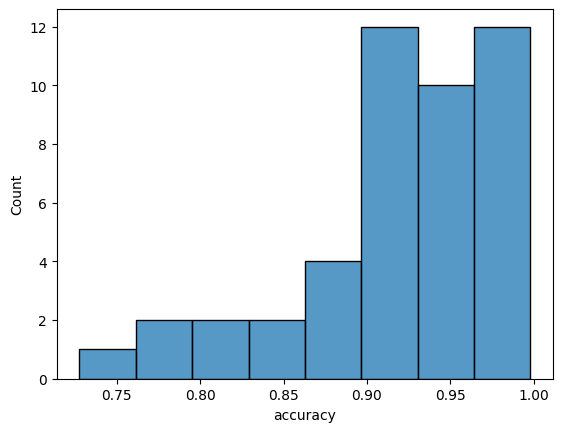

In [6]:
### Load accuracies to add to data
accuracy = pd.read_csv('accuracy.csv', index_col = 0)
sns.histplot(accuracy.accuracy)
med = np.median(accuracy.accuracy)
low_subs = list(accuracy.subject[accuracy.accuracy < med])
high_subs = list(accuracy.subject[accuracy.accuracy > med])
print(low_subs)
print(high_subs)

In [18]:
# BIDS_ROOT = '../data/bids'
# layout = BIDSLayout(BIDS_ROOT, derivatives = True, regex_search = 'forERP')
# subs = layout.get_subjects(scope = 'erp')
# subs.sort(key = int)
# evokeds = pd.DataFrame()

# for sub in subs:
    
#     # Read epochs
#     epochs = read_epochs(sub, 'forERP')
    
#     # Compute evokeds 
#     conditions = list(epochs.event_id.keys())
#     chans = ['Cz', 'Fz', 'FCz', 'CPz', 'Pz']
#     for c in conditions:
#         target = c[0]
#         tone = c[1]
#         for chan in chans:
#             uV = np.squeeze(epochs[c].average(picks = chan).get_data())
#             t = np.arange(-273, 527)

#             if int(sub) in high_subs:
#                 accuracy = 'high'
#             elif int(sub) in low_subs:
#                 accuracy = 'low'
#             else:
#                 accuracy = 'none'

#             d = {
#                 'sub': sub,
#                 'chan': chan,
#                 'target': target,
#                 'accuracy': accuracy,
#                 'tone': tone,
#                 'msec': t,
#                 'uV': uV
#             }

#             # Bind into dataframe
#             evoked = pd.DataFrame(d)
#             evokeds = pd.concat([evokeds, evoked])
#             evokeds = evokeds.reset_index(drop = True)
            # break
        # break
    # break

# evokeds.to_csv('evokeds.csv', index = False) # REDO THIS
evokeds_csv = pd.read_csv('evokeds.csv')

In [11]:
# Adjust units
evokeds['uV'] = evokeds['uV'] * 1000000
evokeds

,sub,chan,target,accuracy,tone,msec,uV
0,3,Cz,1,low,1,-273,-0.079743
1,3,Cz,1,low,1,-272,-0.093544
2,3,Cz,1,low,1,-271,-0.106012
3,3,Cz,1,low,1,-270,-0.116212
4,3,Cz,1,low,1,-269,-0.124180
...,...,...,...,...,...,...,...
1403995,42,Pz,3,low,3,522,0.838061
1403996,42,Pz,3,low,3,523,0.838007
1403997,42,Pz,3,low,3,524,0.836003
1403998,42,Pz,3,low,3,525,0.833778


### By tone

In [68]:
evokeds_tone_1 = evokeds[evokeds.tone == '1']
evokeds_tone_2 = evokeds[evokeds.tone == '2']
evokeds_tone_3 = evokeds[evokeds.tone == '3']
evokeds_tone_1_csv = evokeds_csv[evokeds_csv.tone == 1]
evokeds_tone_2_csv = evokeds_csv[evokeds_csv.tone == 2]
evokeds_tone_3_csv = evokeds_csv[evokeds_csv.tone == 3]

Text(0.5, 1.0, 'Tone 1')

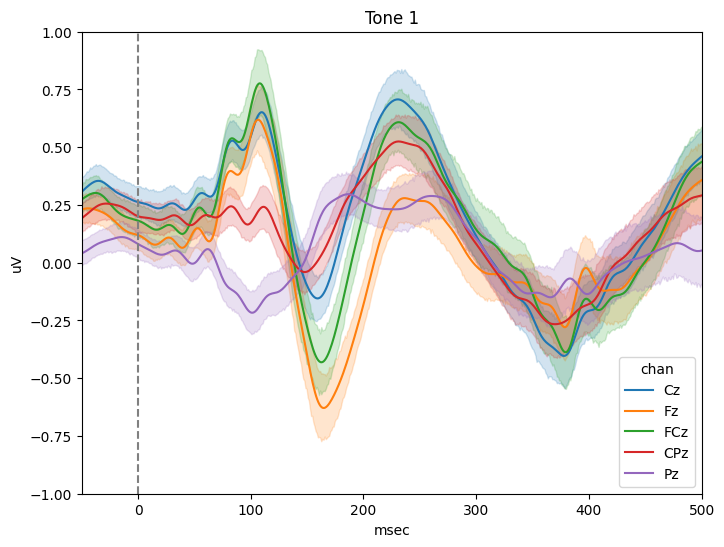

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_1, x = "msec", y = "uV", hue = "chan", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1, 1)
graph.set_title("Tone 1")

Text(0.5, 1.0, 'Tone 2')

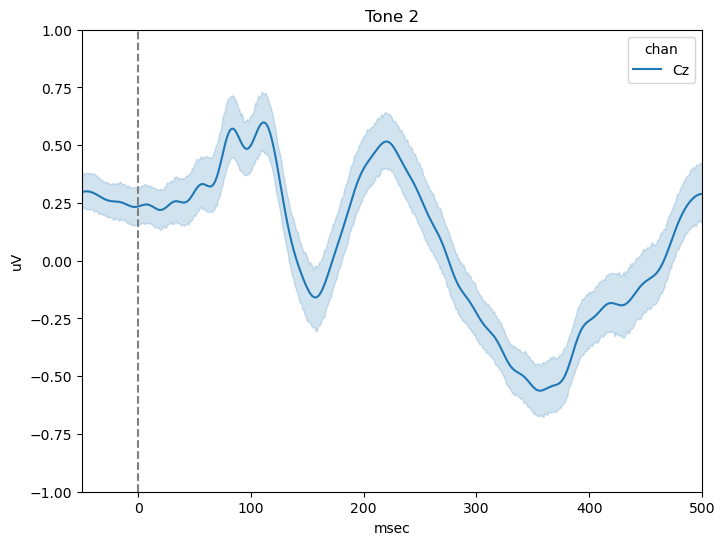

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_2, x = "msec", y = "uV", hue = "chan", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1, 1)
graph.set_title("Tone 2")

Text(0.5, 1.0, 'Tone 3')

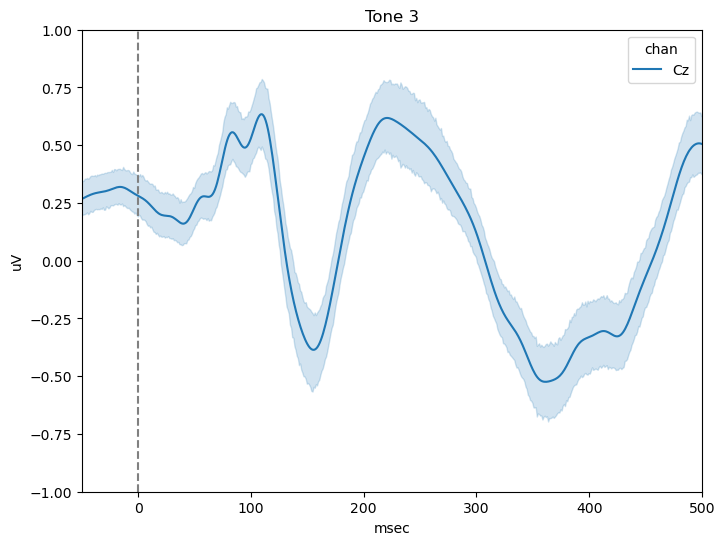

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_3, x = "msec", y = "uV", hue = "chan", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1, 1)
graph.set_title("Tone 3")

### By target and tone

In [70]:
evokeds_tone_1 = evokeds_tone_1[evokeds_tone_1.chan == 'Cz']
evokeds_tone_2 = evokeds_tone_2[evokeds_tone_2.chan == 'Cz']
evokeds_tone_3 = evokeds_tone_3[evokeds_tone_3.chan == 'Cz']
evokeds_tone_1_csv = evokeds_tone_1_csv[evokeds_tone_1_csv.chan == 'Cz']
evokeds_tone_2_csv = evokeds_tone_2_csv[evokeds_tone_2_csv.chan == 'Cz']
evokeds_tone_3_csv = evokeds_tone_3_csv[evokeds_tone_3_csv.chan == 'Cz']

In [72]:
evokeds_tone_1

,sub,chan,target,accuracy,tone,msec,uV
0,3,Cz,1,low,1,-273,-0.079743
1,3,Cz,1,low,1,-272,-0.093544
2,3,Cz,1,low,1,-271,-0.106012
3,3,Cz,1,low,1,-270,-0.116212
4,3,Cz,1,low,1,-269,-0.124180
...,...,...,...,...,...,...,...
1392795,42,Cz,3,low,1,522,0.668616
1392796,42,Cz,3,low,1,523,0.673517
1392797,42,Cz,3,low,1,524,0.676202
1392798,42,Cz,3,low,1,525,0.676989


In [71]:
evokeds_tone_1_csv

,sub,chan,target,accuracy,tone,msec,uV
0,3,Cz,1,low,1,-273,-0.079743
1,3,Cz,1,low,1,-272,-0.093544
2,3,Cz,1,low,1,-271,-0.106012
3,3,Cz,1,low,1,-270,-0.116212
4,3,Cz,1,low,1,-269,-0.124180
...,...,...,...,...,...,...,...
1392795,42,Cz,3,none,1,522,0.668616
1392796,42,Cz,3,none,1,523,0.673517
1392797,42,Cz,3,none,1,524,0.676202
1392798,42,Cz,3,none,1,525,0.676989


/scratch/local/jobs/23180909/ipykernel_1324709/728170884.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  graph = sns.lineplot(data = evokeds_tone_1_csv, x = "msec", y = "uV", style = "target", palette = 'tab10', ax = ax)


Text(0.5, 1.0, 'Tone 1')

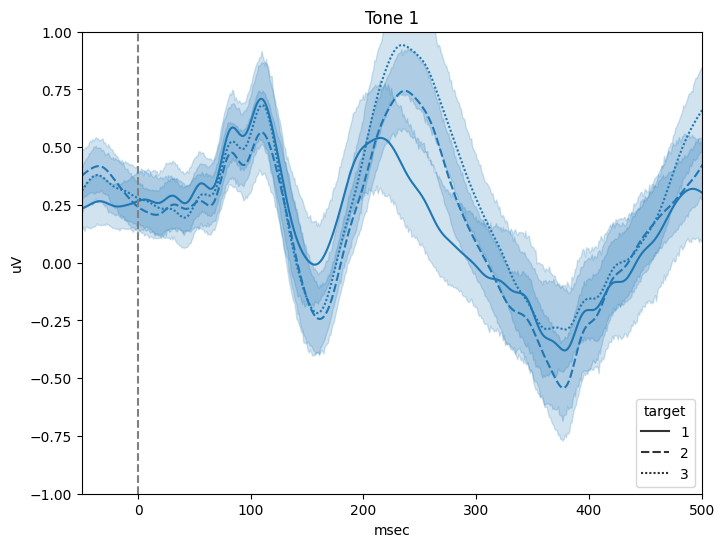

In [73]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_1_csv, x = "msec", y = "uV", style = "target", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1, 1)
graph.set_title('Tone 1')

/scratch/local/jobs/23180909/ipykernel_1324709/2877043459.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  graph = sns.lineplot(data = evokeds_tone_2, x = "msec", y = "uV", style = "target", palette = 'tab10', ax = ax)


Text(0.5, 1.0, 'Tone 2')

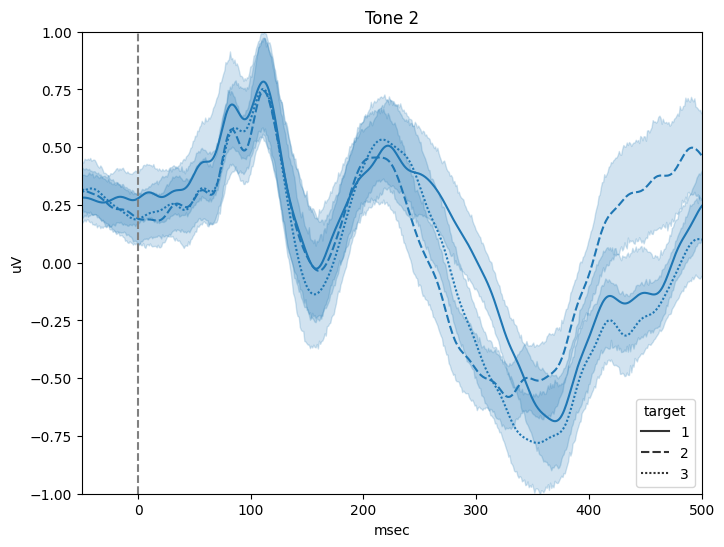

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_2, x = "msec", y = "uV", style = "target", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1, 1)
graph.set_title('Tone 2')

/scratch/local/jobs/23180909/ipykernel_1324709/416824317.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  graph = sns.lineplot(data = evokeds_tone_3, x = "msec", y = "uV", style = "target", palette = 'tab10', ax = ax)


Text(0.5, 1.0, 'Tone 3')

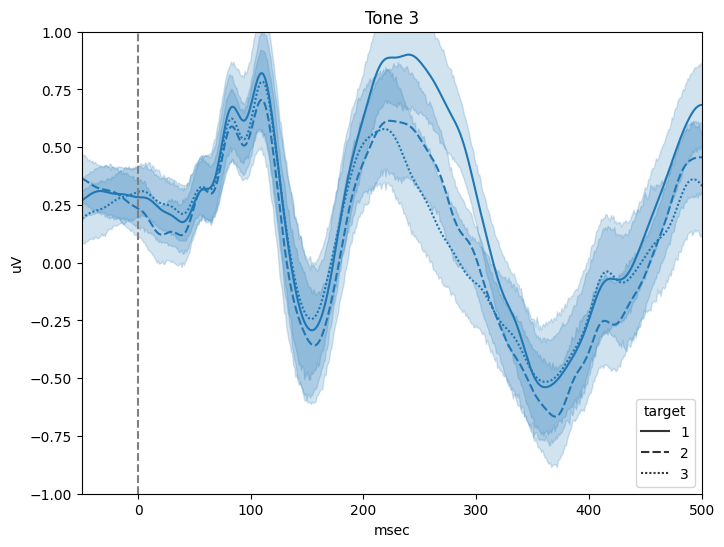

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_3, x = "msec", y = "uV", style = "target", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1, 1)
graph.set_title('Tone 3')

In [43]:
# # import random
# for i in range(0, 1403999):
#     if evokeds_csv.uV.iloc[i] - evokeds.uV.iloc[i] > 0.01:
#         print(evokeds.iloc[i])

KeyError: 0

In [24]:
evokeds_csv.uV[100:200]

100   -0.112972
101   -0.102980
102   -0.092942
103   -0.083009
104   -0.073364
         ...   
195    0.126201
196    0.119114
197    0.108040
198    0.093442
199    0.075922
Name: uV, Length: 100, dtype: float64

# Factor in accuracies

In [69]:
# Drop 'none' accuracies
evokeds_tone_1 = evokeds_tone_1[evokeds_tone_1.accuracy != 'none']
evokeds_tone_2 = evokeds_tone_2[evokeds_tone_2.accuracy != 'none']
evokeds_tone_3 = evokeds_tone_3[evokeds_tone_3.accuracy != 'none']

Text(0.5, 1.0, 'Tone 1')

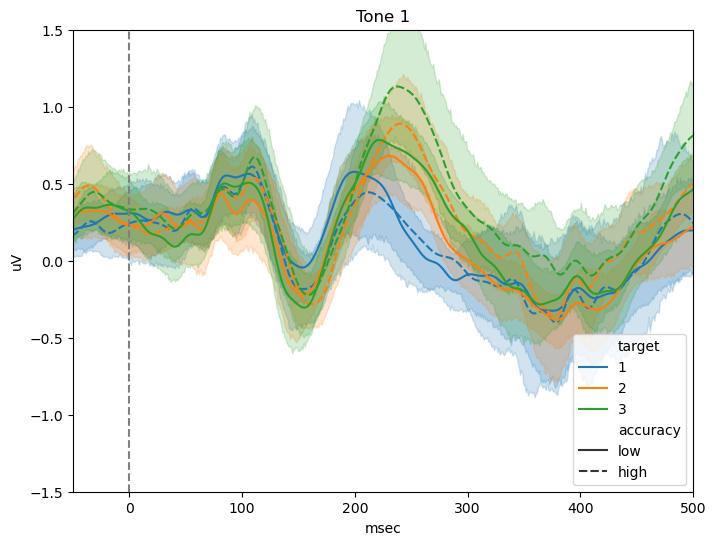

In [70]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_1, x = "msec", y = "uV", hue = "target", style = "accuracy", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1.5, 1.5)
graph.set_title('Tone 1')

Text(0.5, 1.0, 'Tone 2')

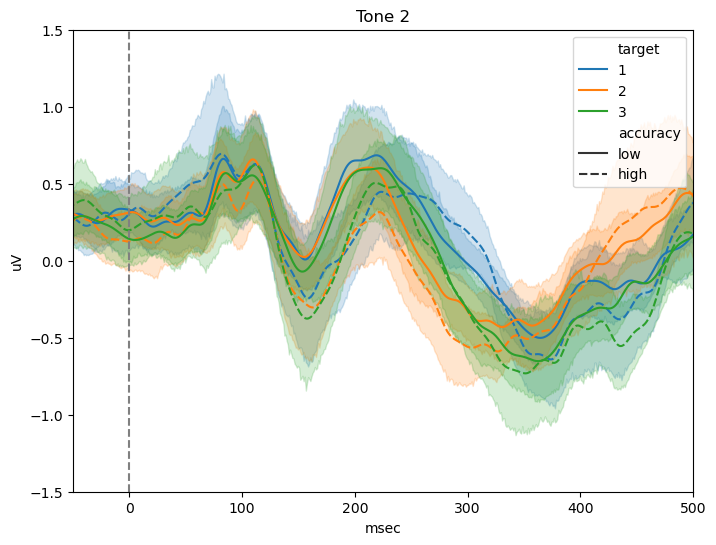

In [71]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_2, x = "msec", y = "uV", hue = "target", style = "accuracy", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1.5, 1.5)
graph.set_title('Tone 2')

Text(0.5, 1.0, 'Tone 3')

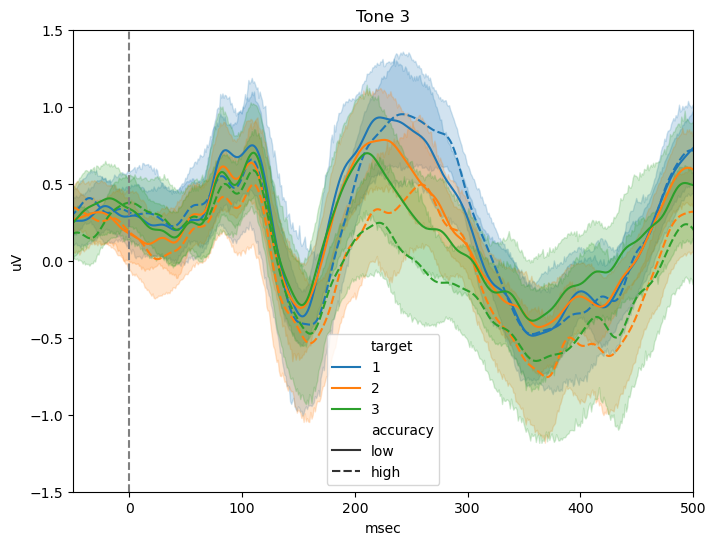

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_3, x = "msec", y = "uV", hue = "target", style = "accuracy", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1.5, 1.5)
graph.set_title('Tone 3')